# LSTM and GRU Networks

            ## 1. Learning objectives

            - Explain gating and memory cells
- Compare LSTM and GRU shapes and parameters
- Train gated sequence classifiers

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Preserve or forget information over longer sequences while reducing vanishing-gradient difficulty.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Gates are learned valves: forget controls retained memory, input controls new information, and output controls exposed state.

## 6. Mathematical foundation

            $$\mathbf{c}_t=\mathbf{f}_t\odot\mathbf{c}_{t-1}+\mathbf{i}_t\odot\tilde{\mathbf{c}}_t.$$

            **Every symbol:**

            - $\mathbf{c}_t$ is the LSTM cell state.
- $\mathbf{f}_t$ is forget gate.
- $\mathbf{i}_t$ is input gate.
- $\tilde{\mathbf{c}}_t$ is candidate memory.
- $\odot$ is elementwise multiplication.

            **Why the equation is needed:** An additive memory path lets gradients and information travel across more time steps.

            **Small numerical example:** With old cell .4, forget .73, input .55, candidate .7, new cell=.73(.4)+.55(.7)=.677.

            **Connection to Python:** nn.LSTM returns both hidden and cell state; nn.GRU combines gating into one hidden state.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def sigmoid_np(values):
    return 1/(1+np.exp(-values))

candidate=.7
previous_cell=.4
forget_gate=sigmoid_np(1.0)
input_gate=sigmoid_np(.2)
new_cell=forget_gate*previous_cell+input_gate*candidate
print("Forget gate:",round(forget_gate,3),"input gate:",round(input_gate,3),"new cell:",round(new_cell,3))

Forget gate: 0.731 input gate: 0.55 new cell: 0.677


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

LSTM model diagnostics: {'input_shape': (225, 16, 1), 'intermediate_shape': (225, 16, 12), 'output_shape': (225, 2), 'trainable_parameters': 746, 'final_training_loss': 0.3896, 'final_validation_loss': 0.4046, 'validation_accuracy': 0.773}
GRU model diagnostics: {'input_shape': (225, 16, 1), 'intermediate_shape': (225, 16, 12), 'output_shape': (225, 2), 'trainable_parameters': 566, 'final_training_loss': 0.3336, 'final_validation_loss': 0.4095, 'validation_accuracy': 0.827}


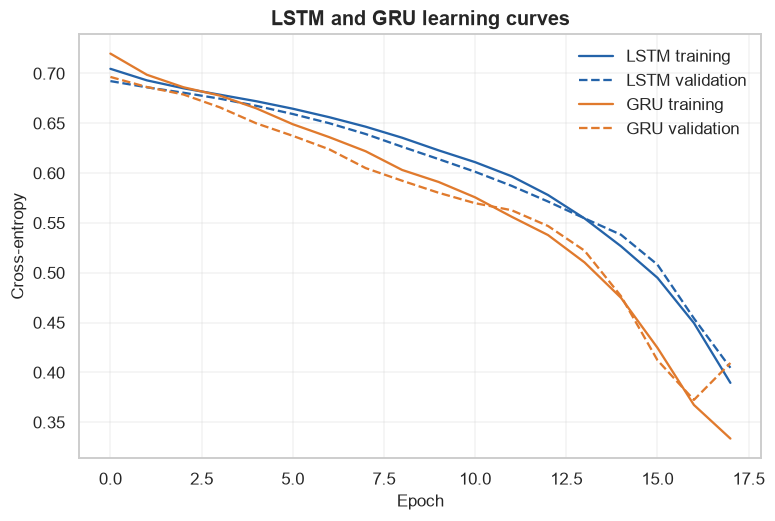

In [3]:
samples=300; time_steps=16
X=rng.normal(size=(samples,time_steps,1)).astype("float32")
y=(X[:,:8,0].sum(axis=1)>X[:,8:,0].sum(axis=1)).astype("int64")
split=225
train_X=torch.tensor(X[:split]); train_y=torch.tensor(y[:split])
validation_X=torch.tensor(X[split:]); validation_y=torch.tensor(y[split:])

class GatedClassifier(nn.Module):
    def __init__(self,kind):
        super().__init__()
        recurrent=nn.LSTM if kind=="LSTM" else nn.GRU
        self.recurrent=recurrent(1,12,batch_first=True)
        self.output=nn.Linear(12,2)
    def forward(self,values):
        sequence,state=self.recurrent(values)
        return self.output(sequence[:,-1]),sequence,state

histories={}; models={}
for kind in ["LSTM","GRU"]:
    model=GatedClassifier(kind); optimizer=torch.optim.Adam(model.parameters(),lr=.02); loss_fn=nn.CrossEntropyLoss()
    train_history=[]; validation_history=[]
    for epoch in range(18):
        model.train(); optimizer.zero_grad(); logits,sequence,state=model(train_X)
        loss=loss_fn(logits,train_y); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad(): val_logits,_,_=model(validation_X); val_loss=loss_fn(val_logits,validation_y)
        train_history.append(loss.item()); validation_history.append(val_loss.item())
    histories[kind]=(train_history,validation_history); models[kind]=(model,val_logits)
    accuracy=(val_logits.argmax(1)==validation_y).float().mean().item()
    print(f"{kind} model diagnostics:", {
        "input_shape": tuple(train_X.shape),
        "intermediate_shape": tuple(sequence.shape),
        "output_shape": tuple(logits.shape),
        "trainable_parameters": sum(p.numel() for p in model.parameters()),
        "final_training_loss": round(train_history[-1], 4),
        "final_validation_loss": round(validation_history[-1], 4),
        "validation_accuracy": round(accuracy, 3),
    })

figure,axis=plt.subplots()
for kind,(train_history,validation_history) in histories.items():
    color=COURSE_COLORS["blue"] if kind=="LSTM" else COURSE_COLORS["orange"]
    axis.plot(train_history,label=f"{kind} training",color=color)
    axis.plot(validation_history,label=f"{kind} validation",color=color,linestyle="--")
axis.set(title="LSTM and GRU learning curves",xlabel="Epoch",ylabel="Cross-entropy"); axis.legend(); plt.show()

**How to interpret the result:** Validation curves compare optimization on the same sequence task; parameter counts clarify the complexity tradeoff.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Hidden size controls memory capacity; LSTM generally has more gate parameters than GRU.

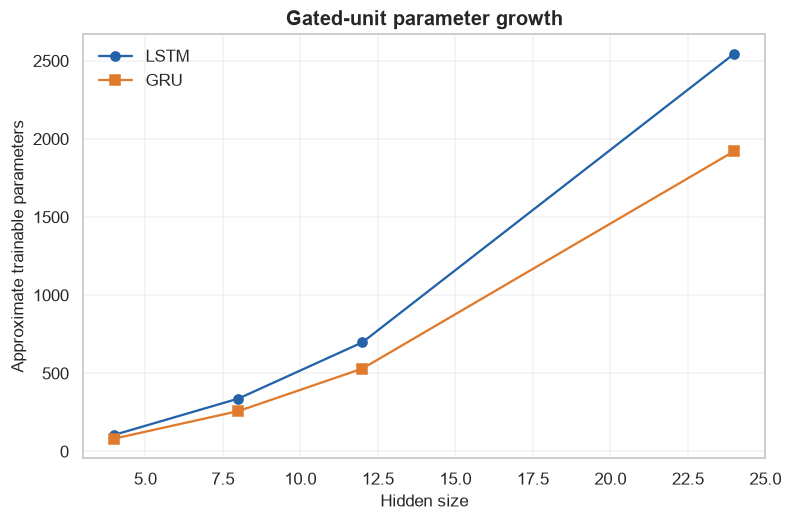

In [4]:
hidden_sizes=[4,8,12,24]
lstm_counts=[4*(1*h+h*h+h) + (2*h+2) for h in hidden_sizes]
gru_counts=[3*(1*h+h*h+h) + (2*h+2) for h in hidden_sizes]
figure,axis=plt.subplots()
axis.plot(hidden_sizes,lstm_counts,marker="o",label="LSTM",color=COURSE_COLORS["blue"])
axis.plot(hidden_sizes,gru_counts,marker="s",label="GRU",color=COURSE_COLORS["orange"])
axis.set(title="Gated-unit parameter growth",xlabel="Hidden size",ylabel="Approximate trainable parameters"); axis.legend(); plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)